Coherence Score for Computer Science and Information Technology Courses



In [ ]:
# Imports 

import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

In [ ]:
# Data Loading

DATA_FILE = Path("out/skills/dcit_courses_skills.jsonl")
if not DATA_FILE.exists():
    raise FileNotFoundError(f"{DATA_FILE} not found.")

df = pd.read_json(DATA_FILE, lines=True)

In [ ]:
# Expanding the DataFrame to have one row per thematic area

df_expanded = df.explode("thematic_areas").rename(columns={"thematic_areas": "thematic_area"})

In [ ]:
# Function to normalize multi-word skills by replacing spaces with underscores

def normalize_multiword_skills(skills):
    if not isinstance(skills, list):
        return []
    return [str(skill).strip().replace(" ", "_") for skill in skills if str(skill).strip()]

df_expanded["skills"] = df_expanded["skills"].apply(normalize_multiword_skills)

In [ ]:
# Function to create separate DataFrames for Computer Science and Information Technology courses

cs_df = df_expanded[df_expanded["thematic_area"]=="computer_science"].copy()
it_df = df_expanded[df_expanded["thematic_area"]=="information_technology"].copy()

cs_texts = cs_df["skills"].tolist()
it_texts = it_df["skills"].tolist()

In [ ]:
# Function to remove thematic area names from the skill lists to prevent them from dominating the topic modeling results
def clean_tokens(tokens):
    return [
        t for t in tokens
        if t not in {"computer_science", "information_technology"}
    ]

cs_texts = [clean_tokens(t) for t in cs_texts]
it_texts = [clean_tokens(t) for t in it_texts]

In [ ]:
# Verifying the cleaned DataFrames

cs_df.head()
it_df.head()

,course_code,course_name,thematic_area,skills
0,COMP 1600,Introduction to Computing Concepts,information_technology,"[address_mode, binary_search_algorithm, comput..."
1,COMP 1601,Computer Programming I,information_technology,"[case, control_structure, problem_solve, progr..."
2,COMP 1602,Computer Programming II,information_technology,"[binary_file, computer_science, data_structure..."
3,COMP 1603,Computer Programming III,information_technology,"[buffer_overflow, case, code_review, computer_..."
4,COMP 1604,Mathematics for Computing,information_technology,"[computer_science, existential_quantification,..."


In [ ]:
# Function to evaluate coherence scores for a range of topic numbers and return the best model and its details
def evaluate_coherence(skills, start=1, limit=20, step=1, no_below=1, no_above=0.8):
    dictionary = Dictionary(skills)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)

    corpus = [dictionary.doc2bow(skill) for skill in skills]

    model_list = []
    coherence_values = []
    topic_range = list(range(start, limit, step))

    for num_topics in topic_range:
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=10,
            iterations=100
        )

        coherence_model = CoherenceModel(
            model=model,
            texts=skills,
            dictionary=dictionary,
            coherence="c_v"
        )

        model_list.append(model)
        coherence_values.append(coherence_model.get_coherence())

        # print(f"Number of Topics: {num_topics}, Coherence Score:{coherence_model.get_coherence():.4f}")

    # best_value = max(coherence_values)
    best_index = coherence_values.index(max(coherence_values))
    # topics = model.print_topics(num_words=10)

    # print(f"Optimal Number of Topics: {best_index+1}")
    # print(f"Coherence Score: {best_value:.4f}")
    # print("\nTop 10 Words per Topic:")
    # for topic_num, topic_words in topics:
    #     print(f"Topic: {topic_num}: {topic_words}")

    return {
        "dictionary": dictionary,
        "corpus": corpus,
        "topic_range": topic_range,
        "model_list": model_list,
        "coherence_values": coherence_values,
        "best_model": model_list[best_index],
        "best_num_topics": topic_range[best_index],
        "best_coherence": coherence_values[best_index],
    }


Computer Science Topic Evaluation


Computer Science Coherence Scores: 
Number of Topics: 1, Coherence Score: 0.3013
Number of Topics: 2, Coherence Score: 0.3550
Number of Topics: 3, Coherence Score: 0.4353
Number of Topics: 4, Coherence Score: 0.4345
Number of Topics: 5, Coherence Score: 0.4217
Number of Topics: 6, Coherence Score: 0.4069
Number of Topics: 7, Coherence Score: 0.4365
Number of Topics: 8, Coherence Score: 0.5577
Number of Topics: 9, Coherence Score: 0.5449
Number of Topics: 10, Coherence Score: 0.5218
Number of Topics: 11, Coherence Score: 0.4950
Number of Topics: 12, Coherence Score: 0.6004
Number of Topics: 13, Coherence Score: 0.5007
Number of Topics: 14, Coherence Score: 0.7607
Number of Topics: 15, Coherence Score: 0.6750
Number of Topics: 16, Coherence Score: 0.6362
Number of Topics: 17, Coherence Score: 0.6359
Number of Topics: 18, Coherence Score: 0.5847
Number of Topics: 19, Coherence Score: 0.5860


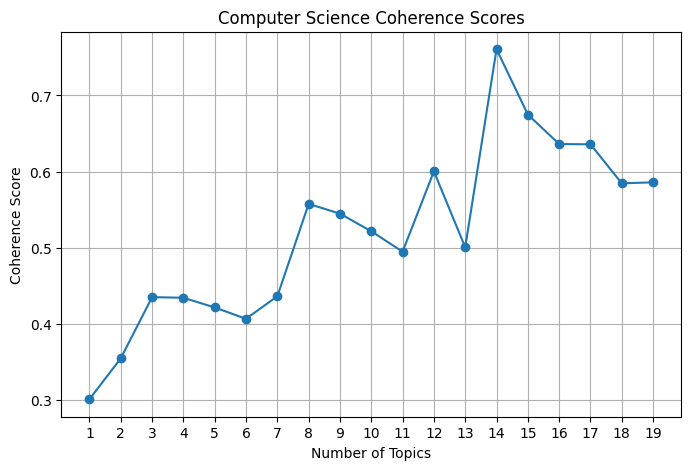

Optimal Number of Topics: 14
Coherence Score: 0.7607

Top 10 Words per Topic 14: 

Topic: 0: 0.024*"text_file" + 0.024*"data_structure" + 0.024*"linear_search" + 0.024*"priority_queue" + 0.024*"programming_concept" + 0.024*"time_complexity" + 0.024*"search_algorithm" + 0.024*"binary_file" + 0.024*"random_number_generation" + 0.024*"software_system"

Topic: 1: 0.032*"problem_solve" + 0.025*"software_system" + 0.019*"project_management" + 0.019*"system_software" + 0.013*"software_design" + 0.013*"software_development" + 0.013*"software_quality" + 0.013*"verification_and_validation" + 0.013*"system_testing" + 0.013*"functional_requirement"

Topic: 2: 0.024*"case" + 0.024*"access_control" + 0.013*"direct_memory_access" + 0.013*"share_memory" + 0.013*"memory_system" + 0.013*"kernel_mode" + 0.013*"resource_allocation" + 0.013*"mac_os_x" + 0.013*"computer_network" + 0.013*"context_switch"

Topic: 3: 0.025*"intelligent_system" + 0.013*"problem_solve" + 0.013*"decision_theory" + 0.013*"social_s

In [44]:
cs_results = evaluate_coherence(cs_texts, start=1, limit=20, step=1)

print("Computer Science Coherence Scores: ")
for k, score in zip(cs_results["topic_range"], cs_results["coherence_values"]):
    print(f"Number of Topics: {k}, Coherence Score: {score:.4f}")


plt.figure(figsize=(8, 5))
plt.plot(cs_results["topic_range"], cs_results["coherence_values"], marker="o")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Computer Science Coherence Scores")
plt.xticks(cs_results["topic_range"])
plt.grid(True)
plt.show()

print(f"Optimal Number of Topics: {cs_results['best_num_topics']}")
print(f"Coherence Score: {cs_results['best_coherence']:.4f}")
topics = cs_results["best_model"].print_topics(num_words=10)
print(f"\nTop 10 Words per Topic {cs_results['best_num_topics']}: ")
for topic_num, topic_words in topics:
    print(f"\nTopic: {topic_num}: {topic_words}")


Information Technology Topic Evaluation 